In [ ]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('../lib')

In [ ]:
from load_netmob import Load_NetMob

df = Load_NetMob()

df.remove_blurring()

initializing spark session ...
merging datasets ...
merging with trips ...
merging with individuals ...
merging with weather ...
Remove blurring effect ...


In [10]:
df.data.show(5)

+-------+-----------+----------+-----+-------------------+-----+-------------------+------------+----+-----------+-----------------+--------------------+--------+----------+--------+------------+------------+------------+------------+------+------+--------+--------+--------+---------+-----------+---------+------------+---------------+----------------+----------------+--------------------+--------------+---------------+-----------------+-----------------+-----------------+-----------+-----------+-------------------+--------------------+-------------------+--------------------+-------------------+-------------------+------+------------+---+-------+------------+----+-------------+-----------+-------------+----+----+----+----+
|     ID|   LATITUDE| LONGITUDE|SPEED|     LOCAL DATETIME|VALID|       UTC DATETIME|      fclass|name|index_right| distance_to_road|                 KEY| Day_EMG|  Date_EMG|Day_Type|ID_Trip_Days|Type_Trip_OD|Code_INSEE_O|Code_INSEE_D|Zone_O|Zone_D|  Time_O|  Time_D|D

In [11]:
df.data.count()

4335029

In [29]:
hour_group = df.data\
  .groupBy(hour(col('LOCAL DATETIME')), 'Zone_O')\
  .agg(
    sum(col('Weight_Day'))
  )\
  .toPandas()

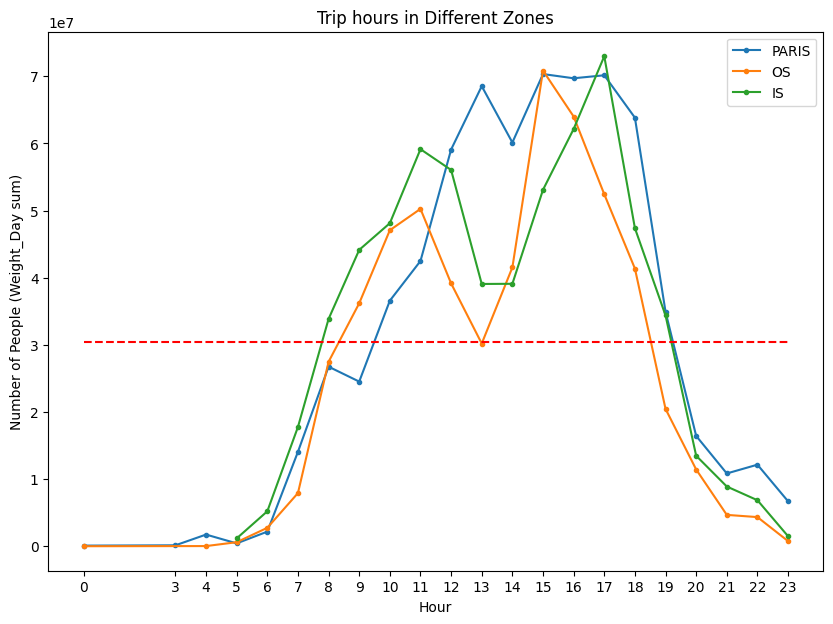

In [63]:
hour_group_sorted = hour_group.sort_values(by='hour(LOCAL DATETIME)')
PARIS = hour_group_sorted[hour_group_sorted['Zone_O'] == 'PARIS']
OS = hour_group_sorted[hour_group_sorted['Zone_O'] == 'OS']
IS = hour_group_sorted[hour_group_sorted['Zone_O'] == 'IS']

h = hour_group_sorted['hour(LOCAL DATETIME)'].unique()
h.sort()

plt.figure(figsize=(10, 7))
plt.plot(
  PARIS['hour(LOCAL DATETIME)'], 
  PARIS['sum(Weight_Day)'],
  marker='o',
  markersize=3,
  label='PARIS'
  )

plt.plot(
  OS['hour(LOCAL DATETIME)'], 
  OS['sum(Weight_Day)'],
  marker='o',
  markersize=3,
  label='OS'
  )

plt.plot(
  IS['hour(LOCAL DATETIME)'], 
  IS['sum(Weight_Day)'],
  marker='o',
  markersize=3,
  label='IS'
  )

plt.title("Trip hours in Different Zones")
plt.xlabel("Hour")
plt.ylabel("Number of People (Weight_Day sum)")
plt.xticks(h, h)
plt.legend()
plt.hlines(
  y=hour_group_sorted['sum(Weight_Day)'].mean(),
  xmin=0,
  xmax=23,
  colors='red',
  linestyles='--'
  )
plt.show()